Analysis of the cell survival data with LQ fit according to unweighted Rørvik. 

In [2]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
import statsmodels.api as sm
import seaborn

In [3]:
def Rorvik_fit(sample):
    #input
    #sample = pandas dataframe with dose, let, survival for given radiation type

    #output = fit data

    #Generate a design matrix of the format 'dose, LET*dose, dose^2, log survival
    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X = np.column_stack((dose, dose*let, np.square(dose)))
    y = -(np.log(np.array(sample['Survival'], dtype = 'float')))

    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary())

    return results.params

In [4]:
def Parse_data(doselevels, platingnumbers, input):
    #Split colony counting data into cell survival for each sample, normalised to control

    #inputs:
    #doselevels = list of the used dose levels
    #platingnumbers = list of the plating numbers for each dose level
    #input = dataframe with the dose and count for each sample

    #Isolate controls
    control_data = input[input['Dose'] == 0]
    control_survival = control_data['Count'].mean()/platingnumbers[0]

    #Write other data to output with dose and survival
    data = input[input['Dose'] != 0]
    output = pd.DataFrame(columns=['Dose', 'Survival'])

    for row in data.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        plating_nr = platingnumbers[doselevels.index(row.Dose)]
        newrow['Survival'] = (row.Count/plating_nr)/control_survival
        newrow = pd.DataFrame([newrow])
        output = pd.concat([output, newrow], ignore_index=True)

    return output




In [5]:
#Import data
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results\Results 16 October.xlsx"
data = pd.read_excel(path)

#Set dose levels and used plating numbers
Dose_levels = [0, 2, 5, 8]
Plating_numbers = [500, 1000, 3000, 6000]

In [6]:
#Processing of data

#Split data into radiation types
X_ray_samples = data[data['Rad'] == 'X']
Proton_low_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton H')]
Proton_high_samples = data[(data['Rad'] != 'X') & (data['Rad'] != 'Proton L')]

#Transform data into cell survival
X_survival = Parse_data(Dose_levels, Plating_numbers, X_ray_samples)
PL_survival = Parse_data(Dose_levels, Plating_numbers, Proton_low_samples)
PH_survival = Parse_data(Dose_levels, Plating_numbers, Proton_high_samples)

#Remove any zero survivals
X_survival = X_survival[X_survival['Survival'] != 0]
PL_survival = PL_survival[PL_survival['Survival'] != 0]
PH_survival = PH_survival[PH_survival['Survival'] != 0]

#Correct X_ray dose
#X_survival['Dose'] = 0.72*X_survival['Dose']

#Add LET variable: values obtained from RayStation simulations (analysis in file 'Analysis of RayStation simulations')
X_survival.insert(1, 'LET', 1.00) #keV/um
PL_survival.insert(1, 'LET', 1.26) #keV/um
PH_survival.insert(1, 'LET', 12.33) #keV/um

#Aggregate data back into one dataframe
total_data = pd.concat([X_survival, PL_survival, PH_survival])

#Fit curve
params = Rorvik_fit(total_data)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.932
Model:                            OLS   Adj. R-squared (uncentered):              0.924
Method:                 Least Squares   F-statistic:                              105.7
Date:                Mon, 03 Nov 2025   Prob (F-statistic):                    1.35e-13
Time:                        10:42:31   Log-Likelihood:                         -36.394
No. Observations:                  26   AIC:                                      78.79
Df Residuals:                      23   BIC:                                      82.56
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\bhaan\AppData\Local\Temp\ipykernel_14604\154992488.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, newrow], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_14604\154992488.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, newrow], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_14604\154992488.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecat

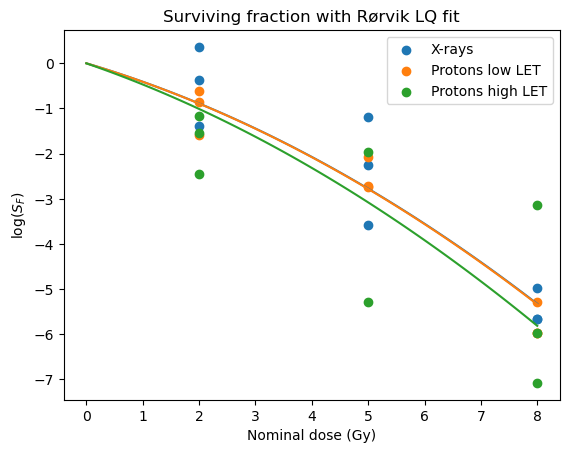

In [12]:
#Plot data
d = np.linspace(0,8,100)
let = X_survival['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(X_survival['Dose'], np.log(X_survival['Survival']), label='X-rays')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PL_survival['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PL_survival['Dose'], np.log(PL_survival['Survival']), label='Protons low LET')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PH_survival['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PH_survival['Dose'], np.log(PH_survival['Survival']), label='Protons high LET')
plt.plot(d, y)

#Customise
plt.xlabel('Nominal dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_14604\4238516390.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


Text(0.5, 0.92, 'RBE as function of dose and LET, Rørvik')

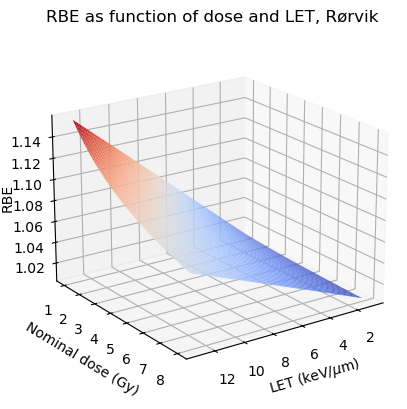

In [13]:
letvals = np.linspace(1, 13, 100)
dosevals = np.linspace(1, 8, 100)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=55, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'coolwarm')
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title('RBE as function of dose and LET, Rørvik')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_14604\1626334991.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


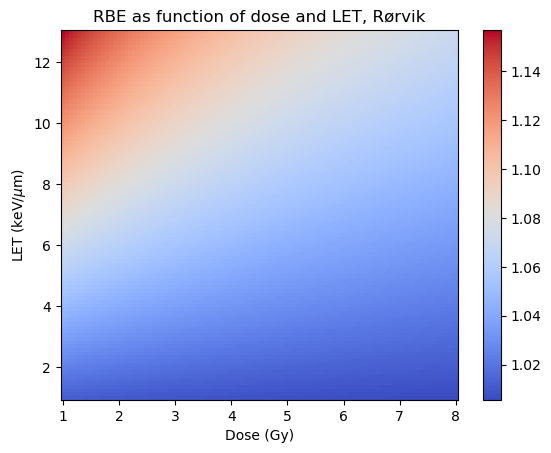

In [14]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='coolwarm')
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()